In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Importer la librairie pandas (toujours nécessaire)
import pandas as pd

# --- MODIFICATION ICI ---
# Chemin vers ton fichier CSV dans Colab
# Si tu l'as téléversé directement, le chemin est juste le nom du fichier.
file_path = "/content/drive/My Drive/Machine learning/Housing_Price_Data.csv"

# Charger les données depuis TON fichier CSV dans un DataFrame pandas
try:
    df = pd.read_csv(file_path)
    print(f"Fichier '{file_path}' chargé avec succès !")
except FileNotFoundError:
    print(f"ERREUR : Le fichier '{file_path}' n'a pas été trouvé.")
    print("Assure-toi de l'avoir bien téléversé dans Colab (vérifie le nom et l'emplacement dans la barre latérale gauche).")
    # Arrêter l'exécution si le fichier n'est pas trouvé pour éviter d'autres erreurs
    # Tu peux commenter la ligne ci-dessous si tu veux continuer malgré l'erreur
    raise # Cette ligne arrête le script en cas d'erreur FileNotFoundError

# --- Le reste du code est IDENTIQUE, car il travaille sur le DataFrame 'df' ---

# Afficher les 5 premières lignes du tableau pour voir à quoi ressemblent TES données
print("\nAperçu des 5 premières lignes de TES données :")
print(df.head())

# Afficher des informations générales sur TON tableau (types de colonnes, valeurs non nulles)
print("\nInformations générales sur TON DataFrame :")
df.info()

# Afficher quelques statistiques de base pour les colonnes numériques de TES données
print("\nStatistiques descriptives de TES données :")
print(df.describe())

# --- Point important pour la suite ---
# Maintenant que tu as chargé TES données, regarde attentivement les sorties de .info() et .describe().
# Les étapes suivantes (nettoyage, prétraitement) devront être adaptées
# en fonction de la structure EXACTE de TON fichier (noms des colonnes,
# présence de valeurs manquantes, types de données, etc.).

Fichier '/content/drive/My Drive/Machine learning/Housing_Price_Data.csv' chargé avec succès !

Aperçu des 5 premières lignes de TES données :
      price  area  bedrooms  bathrooms  stories mainroad guestroom basement  \
0  13300000  7420         4          2        3      yes        no       no   
1  12250000  8960         4          4        4      yes        no       no   
2  12250000  9960         3          2        2      yes        no      yes   
3  12215000  7500         4          2        2      yes        no      yes   
4  11410000  7420         4          1        2      yes       yes      yes   

  hotwaterheating airconditioning  parking prefarea furnishingstatus  
0              no             yes        2      yes        furnished  
1              no             yes        3       no        furnished  
2              no              no        2      yes   semi-furnished  
3              no             yes        3      yes        furnished  
4              no          

In [ ]:
# --- Étape 2 : Prétraitement et Nettoyage (Adapté à tes données) ---

# 2.1 Gestion des Valeurs Manquantes
# Vérification (même si info() a dit non)
print("\nVérification des valeurs manquantes :")
print(df.isnull().sum())
print("-> Aucune valeur manquante à traiter, super !")

# 2.2 Séparation des caractéristiques (X) et de la cible (y) AVANT l'encodage
# C'est une bonne pratique de séparer X et y tôt.
X = df.drop('price', axis=1) # Toutes les colonnes SAUF 'price'
y = df['price']             # SEULEMENT la colonne 'price'

print("\nForme de X (caractéristiques) avant encodage:", X.shape)
print("Forme de y (cible) :", y.shape)
print("\nPremières lignes de X :")
print(X.head())

# 2.3 Encodage des Variables Qualitatives (Texte)
# Les modèles ML ne comprennent que les nombres. On doit convertir les colonnes 'object'.

# Identifier les colonnes 'object' (on les connaît grâce à df.info())
colonnes_object = X.select_dtypes(include=['object']).columns
print(f"\nColonnes de type 'object' à encoder : {list(colonnes_object)}")

# Stratégie d'encodage :
# a) Pour les colonnes binaires ('yes'/'no') : on peut les remplacer par 1/0.
# b) Pour 'furnishingstatus' (qui a plus de 2 catégories) : on utilise le One-Hot Encoding.

# a) Encodage des colonnes 'yes'/'no'
colonnes_oui_non = ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea']
for col in colonnes_oui_non:
    # .map permet de remplacer des valeurs spécifiques
    X[col] = X[col].map({'yes': 1, 'no': 0})
    # On vérifie que ça a bien été transformé en nombre (int)
    print(f"Colonne '{col}' encodée en 1/0. Nouveau type : {X[col].dtype}")

print("\nX après encodage oui/non (aperçu) :")
print(X.head())

# b) Encodage de 'furnishingstatus' avec One-Hot Encoding
# pd.get_dummies crée de nouvelles colonnes pour chaque catégorie
# drop_first=True enlève une colonne pour éviter la redondance (ex: si ce n'est pas 'furnished' ou 'semi-furnished', c'est forcément 'unfurnished')
X = pd.get_dummies(X, columns=['furnishingstatus'], drop_first=True, dtype=int) # dtype=int pour avoir 0/1

print("\nX après One-Hot Encoding de 'furnishingstatus' (aperçu) :")
print(X.head())
print("\nNouvelles colonnes créées :", X.columns) # Voir les nouvelles colonnes

# Vérifier les types de données de X maintenant (tout devrait être numérique)
print("\nTypes de données dans X après tout l'encodage :")
X.info() # Normalement, plus aucune colonne 'object' dans X !

# 2.4 Normalisation des Données
# Maintenant que tout X est numérique, on peut normaliser pour mettre sur la même échelle.
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
# On applique sur TOUT X, car toutes les colonnes sont maintenant numériques
X_scaled = scaler.fit_transform(X)

# Convertir le résultat (qui est un tableau NumPy) en DataFrame pandas pour lisibilité
# C'est bien d'utiliser les colonnes de X pour nommer les colonnes du DataFrame normalisé
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

print("\nAperçu des données X normalisées (X_scaled_df) :")
print(X_scaled_df.head())
print("\nMoyenne de chaque colonne après normalisation (proche de 0) :")
print(X_scaled_df.mean())
print("\nÉcart-type de chaque colonne après normalisation (proche de 1) :")
print(X_scaled_df.std())

# 2.5 Division des Données (Entraînement / Test)
# On utilise notre X_scaled_df (X traité) et notre y d'origine
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_scaled_df, y, test_size=0.2, random_state=42)

# Vérifier les tailles
print(f"\nTaille X_train : {X_train.shape}")
print(f"Taille X_test : {X_test.shape}")
print(f"Taille y_train : {y_train.shape}")
print(f"Taille y_test : {y_test.shape}")

print("\n--- Prétraitement terminé ! ---")
print("Nous avons maintenant X_train, X_test, y_train, y_test prêts pour entraîner et évaluer le modèle.")


Vérification des valeurs manquantes :
price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64
-> Aucune valeur manquante à traiter, super !

Forme de X (caractéristiques) avant encodage: (545, 12)
Forme de y (cible) : (545,)

Premières lignes de X :
   area  bedrooms  bathrooms  stories mainroad guestroom basement  \
0  7420         4          2        3      yes        no       no   
1  8960         4          4        4      yes        no       no   
2  9960         3          2        2      yes        no      yes   
3  7500         4          2        2      yes        no      yes   
4  7420         4          1        2      yes       yes      yes   

  hotwaterheating airconditioning  parking prefarea furnishingstatus  
0              no   

In [5]:
# --- Étape 3 : Construction et Entraînement du Modèle ---

# On va utiliser le modèle le plus simple pour commencer : la Régression Linéaire

# Importer la classe du modèle depuis scikit-learn
from sklearn.linear_model import LinearRegression

# 1. Créer une instance du modèle
# C'est comme créer un "plan" vide pour notre modèle.
linear_model = LinearRegression()

# 2. Entraîner le modèle (c'est ici que "l'apprentissage" se fait)
# On utilise la méthode .fit() avec les données d'entraînement :
# X_train (caractéristiques normalisées d'entraînement)
# y_train (prix réels correspondants)
print("\nEntraînement du modèle de Régression Linéaire en cours...")
linear_model.fit(X_train, y_train)
print("Entraînement terminé !")

# Le modèle 'linear_model' contient maintenant les informations apprises
# à partir des données d'entraînement. Il est prêt à faire des prédictions.


Entraînement du modèle de Régression Linéaire en cours...
Entraînement terminé !


In [6]:
# --- Étape 4 : Évaluation et Validation des Performances ---

# Importer les fonctions nécessaires pour calculer les métriques
from sklearn.metrics import mean_squared_error, r2_score

# 1. Faire des prédictions sur l'ensemble de test (X_test)
# On utilise la méthode .predict() du modèle entraîné.
print("\nRéalisation des prédictions sur l'ensemble de test...")
y_pred_linear = linear_model.predict(X_test)
print("Prédictions terminées.")

# y_pred_linear contient maintenant les prix prédits par notre modèle
# pour chaque maison dans l'ensemble de test.

# Afficher quelques prédictions vs valeurs réelles pour voir
print("\nComparaison de quelques prédictions et valeurs réelles :")
comparison_df = pd.DataFrame({'Prix Réel (y_test)': y_test, 'Prix Prédit (y_pred_linear)': y_pred_linear})
# Afficher les 10 premières comparaisons
print(comparison_df.head(10))


# 2. Calculer les métriques d'évaluation
# On compare les vrais prix (y_test) avec les prix prédits (y_pred_linear)

# Calcul du MSE
mse_linear = mean_squared_error(y_test, y_pred_linear)

# Calcul du R²
r2_linear = r2_score(y_test, y_pred_linear)

print(f"\n--- Évaluation de la Régression Linéaire sur l'ensemble de test ---")
# Pour le MSE, l'unité est le carré du prix, donc c'est un très grand nombre.
# On peut aussi afficher la Racine Carrée de l'Erreur Quadratique Moyenne (RMSE)
# qui est dans la même unité que le prix et plus facile à interpréter.
rmse_linear = mse_linear**0.5
print(f"Mean Squared Error (MSE) : {mse_linear:,.2f}") # Mettre des virgules pour la lisibilité
print(f"Root Mean Squared Error (RMSE) : {rmse_linear:,.2f}") # RMSE est en unités de prix
print(f"Coefficient de Détermination (R²) : {r2_linear:.4f}") # 4 décimales pour R²

# Interprétation simple du R²
print("\nInterprétation du R² :")
if r2_linear >= 0.7:
    print(f"-> Le modèle explique {r2_linear:.1%} de la variance des prix. C'est un bon début !")
elif r2_linear >= 0.5:
    print(f"-> Le modèle explique {r2_linear:.1%} de la variance des prix. C'est correct, mais peut être amélioré.")
else:
    print(f"-> Le modèle explique seulement {r2_linear:.1%} de la variance des prix. Il faudrait essayer un modèle plus complexe ou vérifier les données.")


Réalisation des prédictions sur l'ensemble de test...
Prédictions terminées.

Comparaison de quelques prédictions et valeurs réelles :
     Prix Réel (y_test)  Prix Prédit (y_pred_linear)
316             4060000                 5.164654e+06
77              6650000                 7.224722e+06
360             3710000                 3.109863e+06
90              6440000                 4.612075e+06
493             2800000                 3.294646e+06
209             4900000                 3.532275e+06
176             5250000                 5.611775e+06
249             4543000                 6.368146e+06
516             2450000                 2.722857e+06
426             3353000                 2.629406e+06

--- Évaluation de la Régression Linéaire sur l'ensemble de test ---
Mean Squared Error (MSE) : 1,754,318,687,330.67
Root Mean Squared Error (RMSE) : 1,324,506.96
Coefficient de Détermination (R²) : 0.6529

Interprétation du R² :
-> Le modèle explique 65.3% de la variance des prix

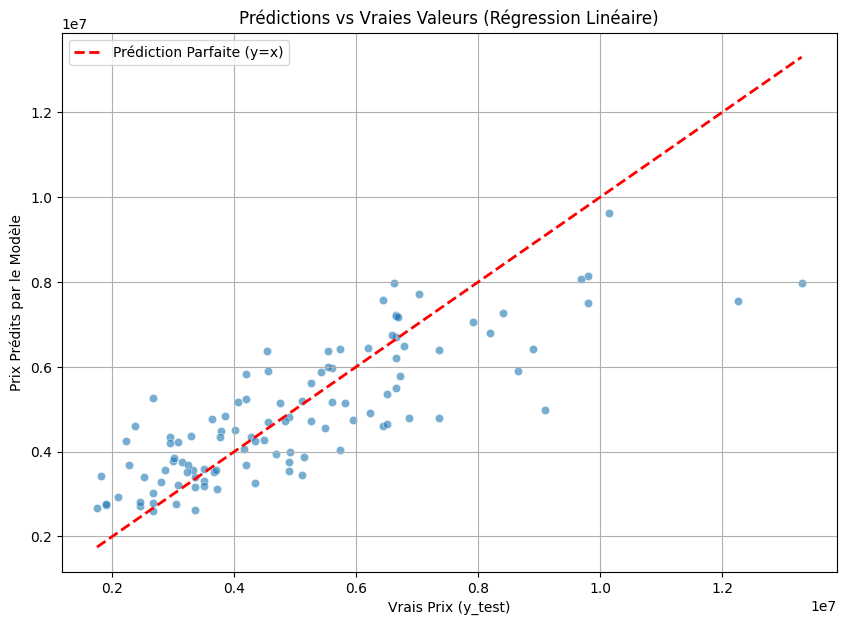

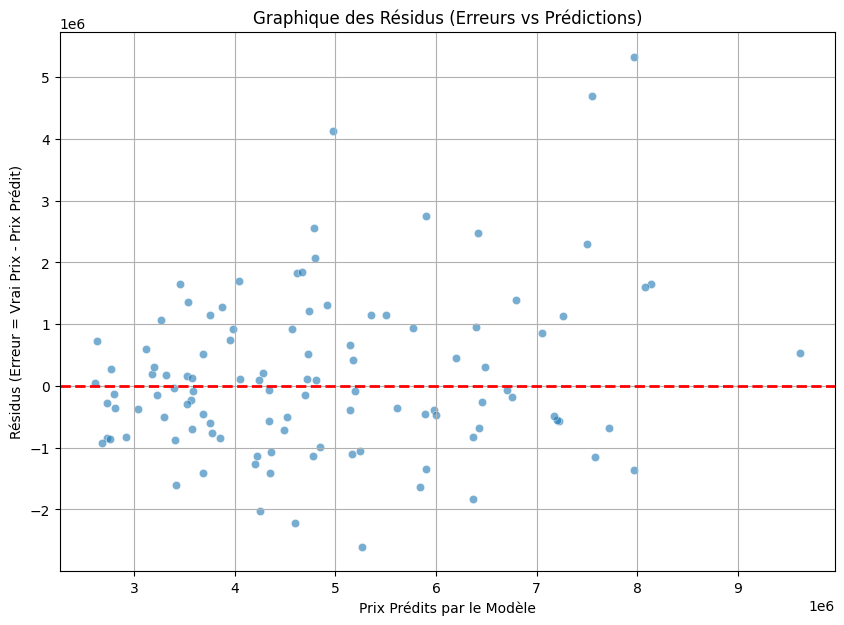

In [7]:
# --- Étape 5 : Visualisation et Interprétation des Résultats ---

# Importer les librairies pour les graphiques
import matplotlib.pyplot as plt
import seaborn as sns

# Créer le graphique de dispersion (scatter plot)
plt.figure(figsize=(10, 7)) # Un peu plus grand pour mieux voir

# Tracer les points : y_test (vrais prix) en abscisse, y_pred_linear (prix prédits) en ordonnée
# alpha=0.6 rend les points un peu transparents, utile s'ils se superposent
sns.scatterplot(x=y_test, y=y_pred_linear, alpha=0.6)

# Ajouter la ligne diagonale rouge (y=x) représentant les prédictions parfaites
# Trouver les min/max pour bien cadrer la ligne
min_val = min(y_test.min(), y_pred_linear.min())
max_val = max(y_test.max(), y_pred_linear.max())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2, label='Prédiction Parfaite (y=x)')

# Ajouter des titres et labels pour la clarté
plt.title('Prédictions vs Vraies Valeurs (Régression Linéaire)')
plt.xlabel('Vrais Prix (y_test)')
plt.ylabel('Prix Prédits par le Modèle')
plt.legend() # Afficher la légende (pour la ligne rouge)
plt.grid(True) # Ajouter une grille pour faciliter la lecture

# Afficher le graphique
plt.show()

# --- Analyse supplémentaire : Visualisation des erreurs (Résidus) ---
# Les résidus sont la différence entre la vraie valeur et la valeur prédite (erreur = y_test - y_pred_linear)
# Un bon modèle devrait avoir des résidus répartis aléatoirement autour de zéro, sans structure particulière.

residuals = y_test - y_pred_linear

plt.figure(figsize=(10, 7))
# Tracer les résidus en fonction des valeurs prédites
sns.scatterplot(x=y_pred_linear, y=residuals, alpha=0.6)
# Ajouter une ligne horizontale à zéro
plt.axhline(y=0, color='red', linestyle='--', linewidth=2)

plt.title('Graphique des Résidus (Erreurs vs Prédictions)')
plt.xlabel('Prix Prédits par le Modèle')
plt.ylabel('Résidus (Erreur = Vrai Prix - Prix Prédit)')
plt.grid(True)
plt.show()

In [8]:
# --- Entraînement et Évaluation d'un modèle Random Forest ---

# Importer la classe du modèle
from sklearn.ensemble import RandomForestRegressor

# 1. Créer une instance du modèle Random Forest
# Principaux paramètres qu'on peut régler (hyperparamètres) :
#   n_estimators : Le nombre d'arbres dans la forêt (plus il y en a, plus c'est long mais souvent mieux, jusqu'à un certain point). Commençons par 100.
#   random_state : Pour la reproductibilité (comme pour train_test_split). Utilisons le même : 42.
#   n_jobs=-1 : (Optionnel) Pour utiliser tous les cœurs du processeur et accélérer l'entraînement si possible.
print("\nCréation du modèle Random Forest...")
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
print("Modèle créé.")

# 2. Entraîner le modèle Random Forest
# On utilise les MÊMES données d'entraînement : X_train, y_train
# Attention : L'entraînement peut prendre un peu plus de temps que la régression linéaire (quelques secondes à peut-être une minute selon la machine).
print("\nEntraînement du modèle Random Forest en cours (cela peut prendre quelques secondes)...")
rf_model.fit(X_train, y_train)
print("Entraînement du Random Forest terminé !")

# 3. Faire des prédictions sur l'ensemble de test (X_test)
print("\nRéalisation des prédictions avec le Random Forest sur l'ensemble de test...")
y_pred_rf = rf_model.predict(X_test)
print("Prédictions terminées.")

# 4. Évaluer le modèle Random Forest
print("\n--- Évaluation du Random Forest sur l'ensemble de test ---")

# Calcul du MSE et RMSE
mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = mse_rf**0.5
print(f"Mean Squared Error (MSE) : {mse_rf:,.2f}")
print(f"Root Mean Squared Error (RMSE) : {rmse_rf:,.2f}")

# Calcul du R²
r2_rf = r2_score(y_test, y_pred_rf)
print(f"Coefficient de Détermination (R²) : {r2_rf:.4f}")

# 5. Comparaison avec la Régression Linéaire
print("\n--- Comparaison des performances ---")
print(f"Régression Linéaire : RMSE = {rmse_linear:,.2f}  | R² = {r2_linear:.4f}")
print(f"Random Forest        : RMSE = {rmse_rf:,.2f}  | R² = {r2_rf:.4f}")

# Analyse de l'amélioration
improvement = r2_rf - r2_linear
if improvement > 0.02: # Si l'amélioration est significative (plus de 2 points de R²)
     print(f"\n-> Le Random Forest améliore significativement le R² de {improvement:.1%}. Très bien !")
elif improvement > 0:
     print(f"\n-> Le Random Forest améliore légèrement le R² de {improvement:.1%}.")
else:
     print("\n-> Le Random Forest n'améliore pas le R² par rapport à la Régression Linéaire (vérifier les paramètres ou les données).")


Création du modèle Random Forest...
Modèle créé.

Entraînement du modèle Random Forest en cours (cela peut prendre quelques secondes)...
Entraînement du Random Forest terminé !

Réalisation des prédictions avec le Random Forest sur l'ensemble de test...
Prédictions terminées.

--- Évaluation du Random Forest sur l'ensemble de test ---
Mean Squared Error (MSE) : 1,962,366,397,823.41
Root Mean Squared Error (RMSE) : 1,400,844.89
Coefficient de Détermination (R²) : 0.6118

--- Comparaison des performances ---
Régression Linéaire : RMSE = 1,324,506.96  | R² = 0.6529
Random Forest        : RMSE = 1,400,844.89  | R² = 0.6118

-> Le Random Forest n'améliore pas le R² par rapport à la Régression Linéaire (vérifier les paramètres ou les données).


In [9]:
# --- Tentative d'Optimisation Simple du Random Forest ---

print("\nTentative d'entraînement d'un Random Forest avec des paramètres ajustés...")

# Créer une nouvelle instance avec des contraintes pour éviter l'overfitting :
#   max_depth=10 : Limite la profondeur de chaque arbre à 10 niveaux.
#   min_samples_leaf=5 : Exige qu'il y ait au moins 5 maisons dans une feuille finale.
rf_model_tuned = RandomForestRegressor(
    n_estimators=100,       # Gardons 100 arbres
    max_depth=10,           # Limiter la profondeur !
    min_samples_leaf=5,     # Exiger plus d'échantillons par feuille !
    random_state=42,
    n_jobs=-1
)
print("Modèle Random Forest ajusté créé.")

# Entraîner ce nouveau modèle
print("\nEntraînement du modèle Random Forest ajusté...")
rf_model_tuned.fit(X_train, y_train)
print("Entraînement terminé.")

# Faire les prédictions
print("\nRéalisation des prédictions avec le Random Forest ajusté...")
y_pred_rf_tuned = rf_model_tuned.predict(X_test)
print("Prédictions terminées.")

# Évaluer le modèle ajusté
print("\n--- Évaluation du Random Forest AJUSTÉ ---")
mse_rf_tuned = mean_squared_error(y_test, y_pred_rf_tuned)
rmse_rf_tuned = mse_rf_tuned**0.5
r2_rf_tuned = r2_score(y_test, y_pred_rf_tuned)
print(f"Mean Squared Error (MSE) : {mse_rf_tuned:,.2f}")
print(f"Root Mean Squared Error (RMSE) : {rmse_rf_tuned:,.2f}")
print(f"Coefficient de Détermination (R²) : {r2_rf_tuned:.4f}")

# Comparaison finale
print("\n--- Comparaison Finale des performances ---")
print(f"Régression Linéaire : RMSE = {rmse_linear:,.2f}  | R² = {r2_linear:.4f}")
print(f"Random Forest (Défaut): RMSE = {rmse_rf:,.2f}  | R² = {r2_rf:.4f}")
print(f"Random Forest (Ajusté): RMSE = {rmse_rf_tuned:,.2f}  | R² = {r2_rf_tuned:.4f}")

# Analyse de l'amélioration par rapport à la régression linéaire
improvement_tuned = r2_rf_tuned - r2_linear
if improvement_tuned > r2_rf - r2_linear: # Si le modèle ajusté est meilleur que le défaut
    print(f"\n-> L'ajustement des paramètres a amélioré le Random Forest !")
    if improvement_tuned > 0.02:
        print(f"-> Le RF ajusté améliore significativement le R² de la Régression Linéaire de {improvement_tuned:.1%}. Excellent !")
    elif improvement_tuned > 0:
         print(f"-> Le RF ajusté améliore légèrement le R² de la Régression Linéaire de {improvement_tuned:.1%}.")
    else:
         print("-> Le RF ajusté est meilleur que le RF par défaut, mais toujours pas meilleur que la Régression Linéaire.")
else:
     print("\n-> L'ajustement des paramètres n'a pas amélioré le Random Forest par rapport au défaut.")


Tentative d'entraînement d'un Random Forest avec des paramètres ajustés...
Modèle Random Forest ajusté créé.

Entraînement du modèle Random Forest ajusté...
Entraînement terminé.

Réalisation des prédictions avec le Random Forest ajusté...
Prédictions terminées.

--- Évaluation du Random Forest AJUSTÉ ---
Mean Squared Error (MSE) : 2,090,561,328,626.99
Root Mean Squared Error (RMSE) : 1,445,877.36
Coefficient de Détermination (R²) : 0.5864

--- Comparaison Finale des performances ---
Régression Linéaire : RMSE = 1,324,506.96  | R² = 0.6529
Random Forest (Défaut): RMSE = 1,400,844.89  | R² = 0.6118
Random Forest (Ajusté): RMSE = 1,445,877.36  | R² = 0.5864

-> L'ajustement des paramètres n'a pas amélioré le Random Forest par rapport au défaut.


In [10]:
# --- Sauvegarde du modèle et du scaler ---

import joblib
import pandas as pd # Assurez-vous que pandas est importé

# 1. Sauvegarder le modèle entraîné (Régression Linéaire)
model_filename = 'linear_regression_model.joblib'
print(f"\nSauvegarde du modèle de Régression Linéaire dans '{model_filename}'...")
joblib.dump(linear_model, model_filename)
print("Modèle sauvegardé.")

# 2. Sauvegarder l'objet scaler (StandardScaler)
# Il est crucial d'utiliser le MÊME scaler pour les nouvelles données !
scaler_filename = 'standard_scaler.joblib'
print(f"\nSauvegarde du scaler dans '{scaler_filename}'...")
# Rappel : la variable 'scaler' a été créée lors de l'étape 2.4
# Assurez-vous qu'elle existe toujours dans votre session Colab.
# Si ce n'est pas le cas, il faudrait la recréer et la ré-entraîner
# sur les données X AVANT l'étape du train/test split :
# from sklearn.preprocessing import StandardScaler
# X_avant_split = df.drop('price', axis=1)
# # ... (faire l'encodage sur X_avant_split comme avant pour obtenir des colonnes numériques)
# scaler_pour_sauvegarde = StandardScaler()
# X_numerique_avant_split = pd.get_dummies(X_avant_split.copy(), columns=['furnishingstatus'], drop_first=True, dtype=int)
# colonnes_oui_non = ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea']
# for col in colonnes_oui_non:
#     X_numerique_avant_split[col] = X_numerique_avant_split[col].map({'yes': 1, 'no': 0}) # Assurez-vous que c'est bien appliqué avant fit_transform
# scaler_pour_sauvegarde.fit(X_numerique_avant_split) # Entraîner le scaler sur TOUT X (avant split mais après encodage)
# joblib.dump(scaler_pour_sauvegarde, scaler_filename) # Sauvegarder celui-ci

# Si la variable 'scaler' originale existe encore (celle créée et utilisée avant le train_test_split sur X), utilisez-la :
joblib.dump(scaler, scaler_filename)
print("Scaler sauvegardé.")

# 3. Sauvegarder la liste des colonnes attendues par le modèle/scaler
# L'ordre des colonnes est important !
# 'X.columns' contient les noms après encodage et avant normalisation (c'est ce qu'il nous faut)
# Assurez-vous que la variable 'X' existe toujours et correspond au DataFrame juste avant l'application du scaler.
# Si 'X' a été modifiée ou supprimée, recréez-la à partir de df, en appliquant l'encodage.
# Exemple pour recréer X si besoin :
# X_pour_colonnes = df.drop('price', axis=1).copy()
# colonnes_oui_non = ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea']
# for col in colonnes_oui_non:
#     X_pour_colonnes[col] = X_pour_colonnes[col].map({'yes': 1, 'no': 0})
# X_pour_colonnes = pd.get_dummies(X_pour_colonnes, columns=['furnishingstatus'], drop_first=True, dtype=int)
# model_columns = list(X_pour_colonnes.columns)

# Si X existe encore (juste avant le scaling) :
model_columns = list(X.columns)
columns_filename = 'model_columns.joblib'
print(f"\nSauvegarde de la liste des colonnes du modèle dans '{columns_filename}'...")
joblib.dump(model_columns, columns_filename)
print("Liste des colonnes sauvegardée.")

print("\nFichiers nécessaires pour l'application Streamlit sauvegardés !")
print("Vérifiez dans la barre latérale gauche de Colab que les fichiers .joblib existent.")


Sauvegarde du modèle de Régression Linéaire dans 'linear_regression_model.joblib'...
Modèle sauvegardé.

Sauvegarde du scaler dans 'standard_scaler.joblib'...
Scaler sauvegardé.

Sauvegarde de la liste des colonnes du modèle dans 'model_columns.joblib'...
Liste des colonnes sauvegardée.

Fichiers nécessaires pour l'application Streamlit sauvegardés !
Vérifiez dans la barre latérale gauche de Colab que les fichiers .joblib existent.


In [11]:
!pip install streamlit -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.3/44.3 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.8/9.8 MB 55.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 54.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.1/79.1 kB 6.3 MB/s eta 0:00:00


In [13]:
!streamlit run /content/drive/MyDrive/Machine learning/app.py

Usage: streamlit run [OPTIONS] TARGET [ARGS]...
Try 'streamlit run --help' for help.

Error: Streamlit requires raw Python (.py) files, but the provided file has no extension.
For more information, please see https://docs.streamlit.io


In [14]:
cd "/content/drive/MyDrive/Machine learning/"

/content/drive/MyDrive/Machine learning


In [16]:
!streamlit run app.py




  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://34.168.174.85:8501

  Stopping...
  Stopping...


In [17]:
cd "/content/drive/MyDrive/Machine learning/"

/content/drive/MyDrive/Machine learning


In [19]:
!pip install pyngrok -q

In [21]:
from pyngrok import ngrok
import subprocess
import os
import time

# Assure-toi d'être dans le bon dossier
try:
    os.chdir("/content/drive/MyDrive/Machine learning/")
except FileNotFoundError:
    print("ERREUR: Dossier '/content/drive/MyDrive/Machine learning/' non trouvé.")
    # Gérer l'erreur comme nécessaire

# Tue les processus potentiellement en cours (bonne pratique)
print("Arrêt des processus ngrok/streamlit existants...")
os.system("pkill ngrok")
os.system("pkill streamlit")
time.sleep(2) # Laisse un peu de temps

# Lance Streamlit en arrière-plan
print("Lancement de Streamlit en arrière-plan...")
# Utilise le port 8501 par défaut de Streamlit
process = subprocess.Popen([
    "streamlit", "run", "app.py", # Remplace par app_test.py si tu veux tester avec la minimale
    "--server.port", "8501",
    "--server.headless", "true", # Important pour Colab
    "--server.enableCORS", "false" # Peut parfois aider
    ])

# Donne un peu de temps à Streamlit pour démarrer
print("Attente du démarrage de Streamlit...")
time.sleep(5)

# Crée un tunnel ngrok vers le port 8501
try:
    print("Création du tunnel ngrok...")
    public_url = ngrok.connect(8501)
    print("********************************************************************")
    print(f" Tunnel Ngrok créé ! Accédez à votre application via : {public_url} ")
    print("********************************************************************")
    # Remarque: Le tunnel reste actif tant que cette cellule Colab est en cours d'exécution
    # ou jusqu'à ce que le processus ngrok soit arrêté.
except Exception as e:
    print(f"ERREUR lors de la création du tunnel ngrok : {e}")
    print("Vérifiez si ngrok n'est pas déjà en cours d'exécution ou s'il y a un problème de connexion.")

# Tu peux laisser cette cellule tourner pour maintenir le tunnel ouvert.
# Pour arrêter le tunnel, tu peux interrompre l'exécution de la cellule.

Arrêt des processus ngrok/streamlit existants...
Lancement de Streamlit en arrière-plan...
Attente du démarrage de Streamlit...
Création du tunnel ngrok...


ERROR:pyngrok.process.ngrok:t=2025-04-28T21:33:32+0000 lvl=eror msg="failed to reconnect session" obj=tunnels.session err="authentication failed: Usage of ngrok requires a verified account and authtoken.\n\nSign up for an account: https://dashboard.ngrok.com/signup\nInstall your authtoken: https://dashboard.ngrok.com/get-started/your-authtoken\r\n\r\nERR_NGROK_4018\r\n"
ERROR:pyngrok.process.ngrok:t=2025-04-28T21:33:32+0000 lvl=eror msg="session closing" obj=tunnels.session err="authentication failed: Usage of ngrok requires a verified account and authtoken.\n\nSign up for an account: https://dashboard.ngrok.com/signup\nInstall your authtoken: https://dashboard.ngrok.com/get-started/your-authtoken\r\n\r\nERR_NGROK_4018\r\n"
ERROR:pyngrok.process.ngrok:t=2025-04-28T21:33:32+0000 lvl=eror msg="terminating with error" obj=app err="authentication failed: Usage of ngrok requires a verified account and authtoken.\n\nSign up for an account: https://dashboard.ngrok.com/signup\nInstall your aut

ERREUR lors de la création du tunnel ngrok : The ngrok process errored on start: authentication failed: Usage of ngrok requires a verified account and authtoken.\n\nSign up for an account: https://dashboard.ngrok.com/signup\nInstall your authtoken: https://dashboard.ngrok.com/get-started/your-authtoken\r\n\r\nERR_NGROK_4018\r\n.
Vérifiez si ngrok n'est pas déjà en cours d'exécution ou s'il y a un problème de connexion.
